**Question 10**

In [14]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv


In [15]:
import pandas as pd

silver_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv")
gold_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv")
oil_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv")

Brent Oil file path: /kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
    Year  Average_Brent_Oil_Price
62  2008                   150.96
34  1980                   149.86
65  2011                   142.12
67  2013                   138.30
66  2012                   135.27


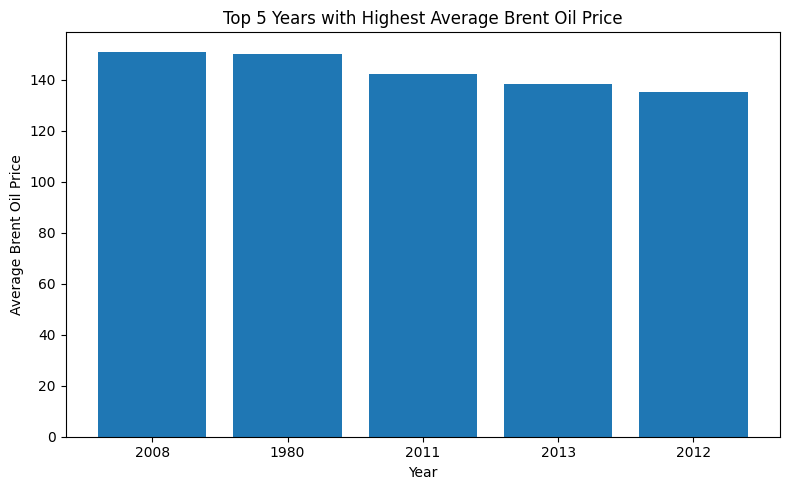

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if "Brent" in filename or "brent" in filename:
            brent_path = os.path.join(dirname, filename)

print("Brent Oil file path:", brent_path)

brent_df = pd.read_csv(brent_path)

brent_df["Date"] = pd.to_datetime(brent_df["Date"], errors="coerce", dayfirst=True)

brent_df["Year"] = brent_df["Date"].dt.year

price_column = "Value"

top5_brent_years = (
    brent_df
    .dropna(subset=["Year", price_column])
    .groupby("Year", as_index=False)[price_column]
    .mean()
    .rename(columns={price_column: "Average_Brent_Oil_Price"})
    .sort_values("Average_Brent_Oil_Price", ascending=False)
    .head(5)
)

top5_brent_years["Year"] = top5_brent_years["Year"].astype(int)
top5_brent_years["Average_Brent_Oil_Price"] = top5_brent_years["Average_Brent_Oil_Price"].round(2)

print(top5_brent_years)

top5_brent_years.to_csv("top5_highest_average_brent_oil_price_years.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(
    top5_brent_years["Year"].astype(str),
    top5_brent_years["Average_Brent_Oil_Price"]
)

plt.title("Top 5 Years with Highest Average Brent Oil Price")
plt.xlabel("Year")
plt.ylabel("Average Brent Oil Price")
plt.tight_layout()
plt.savefig("top5_highest_average_brent_oil_price_years.pdf")
plt.show()